## Homework one main python file

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from bandit_environment import BernoulliBandit
from bandit_algorithm import ExploreThenCommit, EpsilonGreedy
from plotting import finalize_plot

### Explore-Then-Commit

In [2]:
# parameters for bandit
# number of arms
n_arms = 2
# suboptimality gap
delta = 0.2
prob_vec = [0.5 - delta / 2, 0.5 + delta / 2]
# time horizon
time_horizon = 2000

# parameters for explore-then-commit
explore_time_etc = 100
seed_etc = 0  # to fix randomness

# parameters for epsilon-greedy
eps = 0.1
seed_e_greedy = 4195  # to fix randomness
# try seed 4195

In [7]:
# initialise environment
env1 = BernoulliBandit(probabilities=prob_vec, random_seed=seed_etc)
# initialise bandit algorithm
etc_alg = ExploreThenCommit(
    n_arms=n_arms, T_explore=explore_time_etc, random_seed=seed_etc
)

In [8]:
# set up loop
regret = np.zeros(time_horizon)
for timestep in range(time_horizon):
    # algorithm chooses an arm
    chosen_arm = etc_alg.select_arm()
    # environment provides a reward
    reward = env1.pull_arm(chosen_arm)
    # algorithm updates its internal state
    etc_alg.update(chosen_arm, reward)
    # compute regret
    instant_regret = env1.get_regret(chosen_arm)
    if timestep == 0:
        regret[timestep] = instant_regret
    else:
        regret[timestep] = regret[timestep - 1] + instant_regret

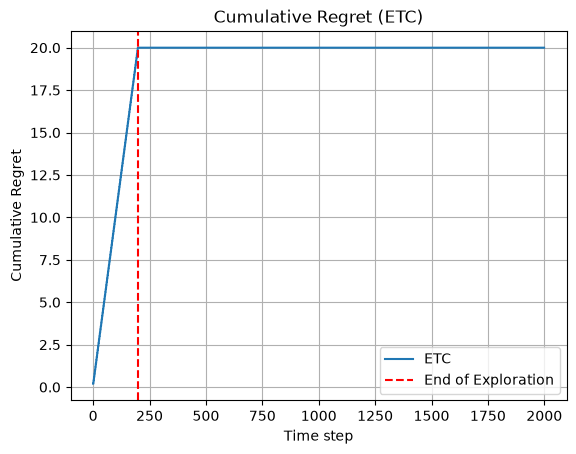

In [11]:
# plot regret
plt.plot(range(time_horizon), regret, label="ETC")
# added dotted vertical line to indicate end of exploration phase
plt.axvline(
    x=n_arms * explore_time_etc, color="r", linestyle="--", label="End of Exploration"
)
finalize_plot(xlabel="Time step", ylabel="Cumulative Regret", title="Cumulative Regret (ETC)")

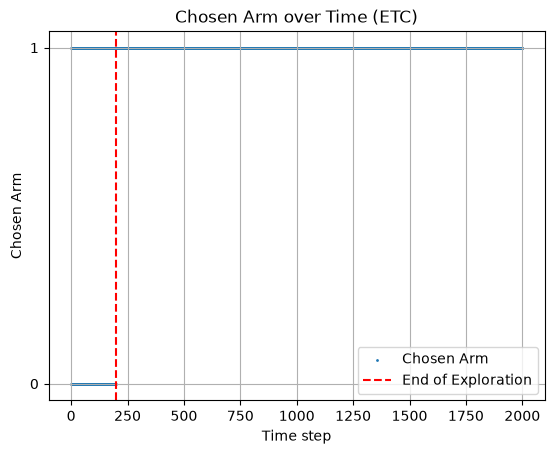

In [12]:
# plot chosen arm
chosen_arms = np.array(etc_alg.arm_history)
plt.scatter(range(time_horizon), chosen_arms, label="Chosen Arm", s=1)
plt.axvline(
    x=n_arms * explore_time_etc, color="r", linestyle="--", label="End of Exploration"
)
plt.yticks(np.arange(n_arms))
finalize_plot(xlabel="Time step", ylabel="Chosen Arm", title="Chosen Arm over Time (ETC)")

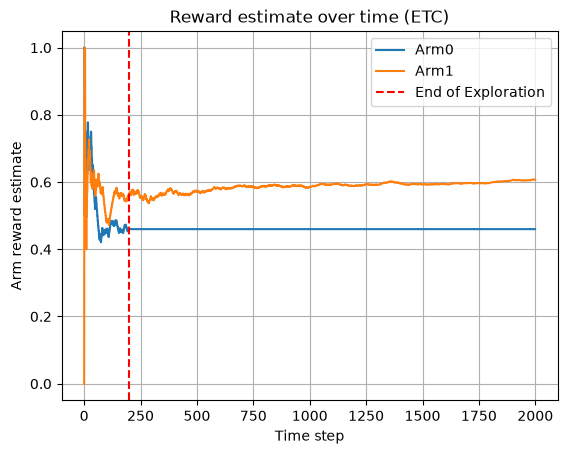

In [13]:
# plot arm estimates over time
for i in range(n_arms):
    plt.plot(range(time_horizon),
             etc_alg.get_arms_estimates_history()[:, i],
             label="Arm" + str(i))
plt.axvline(
    x=n_arms * explore_time_etc, color="r", linestyle="--", label="End of Exploration"
)
finalize_plot(xlabel="Time step", ylabel="Arm reward estimate",title="Reward estimate over time (ETC)")

In [14]:
prob_vec

[0.4, 0.6]

#### c)

In [8]:
# Estimate the probability of committing to the suboptimal arm after 200 pulls.
n_simulations = 10_000
rng_sim = np.random.default_rng(43170)

rewards_arm_0 = rng_sim.binomial(1, prob_vec[0], size=(n_simulations, explore_time_etc))
rewards_arm_1 = rng_sim.binomial(1, prob_vec[1], size=(n_simulations, explore_time_etc))
empirical_means = np.column_stack((rewards_arm_0.mean(axis=1), rewards_arm_1.mean(axis=1)))
selected_arms = np.argmax(empirical_means, axis=1)
suboptimal_arm = int(np.argmin(prob_vec))

n_suboptimal = np.count_nonzero(selected_arms == suboptimal_arm)
p_hat_sub_200 = n_suboptimal / n_simulations
print(f"Suboptimal selections: {n_suboptimal}/{n_simulations}")
print(f"p_hat_sub^200 = {p_hat_sub_200:.4f}")

Suboptimal selections: 25/10000
p_hat_sub^200 = 0.0025


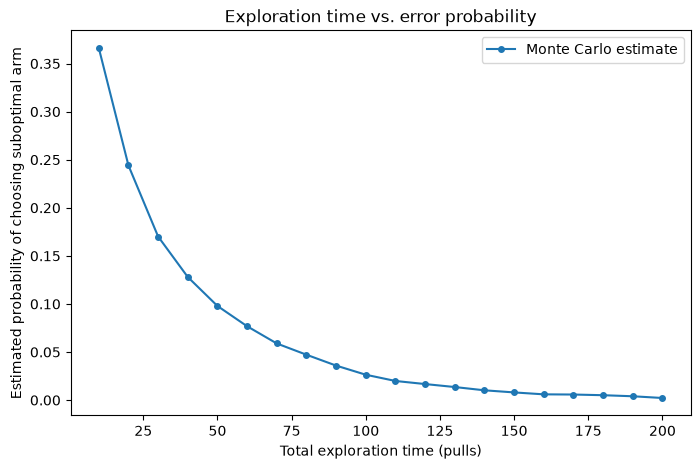

In [9]:
# Estimate the error probability for different exploration durations.
exploration_steps = np.arange(5, 101, 5)
exploration_times = n_arms * exploration_steps
error_probabilities = []
rng_plot = np.random.default_rng(2027)

for pulls_per_arm in exploration_steps:
    rewards_arm_0 = rng_plot.binomial(
        1, prob_vec[0], size=(n_simulations, pulls_per_arm)
    )
    rewards_arm_1 = rng_plot.binomial(
        1, prob_vec[1], size=(n_simulations, pulls_per_arm)
    )
    # np.argmax chooses arm 0 on ties, and arm 0 is suboptimal here.
    error_probabilities.append(
        np.mean(rewards_arm_0.mean(axis=1) >= rewards_arm_1.mean(axis=1))
    )

plt.figure(figsize=(8, 5))
plt.plot(
    exploration_times,
    error_probabilities,
    marker="o",
    markersize=4,
    label="Monte Carlo estimate",
)
plt.grid(True, alpha=0.3)
finalize_plot(
    xlabel="Total exploration time (pulls)",
    ylabel="Estimated probability of choosing suboptimal arm",
    title="Exploration time vs. error probability",
)

#### d)


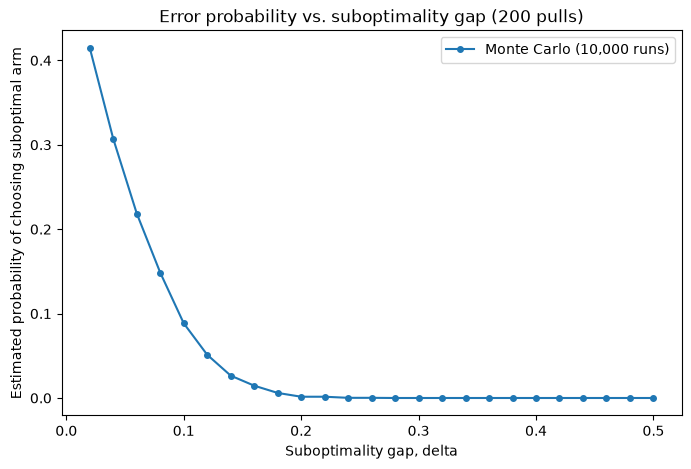

In [10]:
# Estimate p_hat_sub^200 for different suboptimality gaps.
delta_values = np.linspace(0.02, 0.5, 25)
error_probabilities_delta = []
rng_delta = np.random.default_rng(43171)

for gap in delta_values:
    probabilities = [0.5 - gap / 2, 0.5 + gap / 2]
    rewards_arm_0 = rng_delta.binomial(
        1, probabilities[0], size=(n_simulations, explore_time_etc)
    )
    rewards_arm_1 = rng_delta.binomial(
        1, probabilities[1], size=(n_simulations, explore_time_etc)
    )
    empirical_means = np.column_stack(
        (rewards_arm_0.mean(axis=1), rewards_arm_1.mean(axis=1))
    )
    selected_arms = np.argmax(empirical_means, axis=1)
    error_probabilities_delta.append(np.mean(selected_arms == 0))

plt.figure(figsize=(8, 5))
plt.plot(
    delta_values,
    error_probabilities_delta,
    marker="o",
    markersize=4,
    label=f"Monte Carlo ({n_simulations:,} runs)",
)
plt.grid(True, alpha=0.3)
finalize_plot(
    xlabel="Suboptimality gap, delta",
    ylabel="Estimated probability of choosing suboptimal arm",
    title="Error probability vs. suboptimality gap (200 pulls)",
)

#### e)

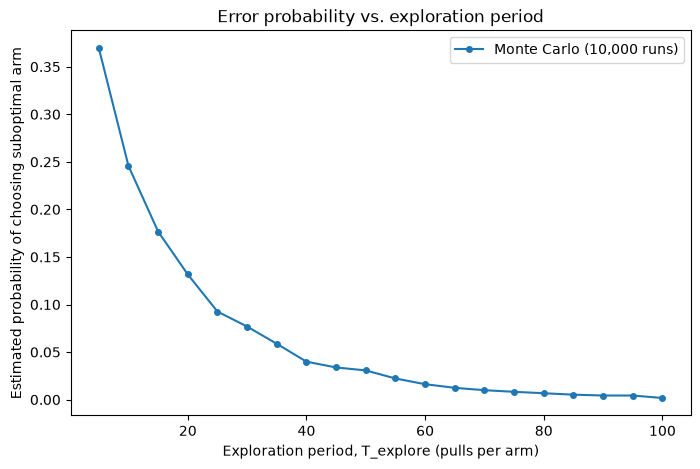

In [11]:
# Estimate p_hat_sub at the end of exploration for different T_explore values.
exploration_periods = np.arange(5, explore_time_etc + 1, 5)
p_hat_sub_by_period = []
rng_period = np.random.default_rng(43172)

for period in exploration_periods:
    rewards_arm_0 = rng_period.binomial(
        1, prob_vec[0], size=(n_simulations, period)
    )
    rewards_arm_1 = rng_period.binomial(
        1, prob_vec[1], size=(n_simulations, period)
    )
    empirical_means = np.column_stack(
        (rewards_arm_0.mean(axis=1), rewards_arm_1.mean(axis=1))
    )
    selected_arms = np.argmax(empirical_means, axis=1)
    p_hat_sub_by_period.append(np.mean(selected_arms == 0))

plt.figure(figsize=(8, 5))
plt.plot(
    exploration_periods,
    p_hat_sub_by_period,
    marker="o",
    markersize=4,
    label=f"Monte Carlo ({n_simulations:,} runs)",
)
plt.grid(True, alpha=0.3)
finalize_plot(
    xlabel="Exploration period, T_explore (pulls per arm)",
    ylabel="Estimated probability of choosing suboptimal arm",
    title="Error probability vs. exploration period",
)


#### f)

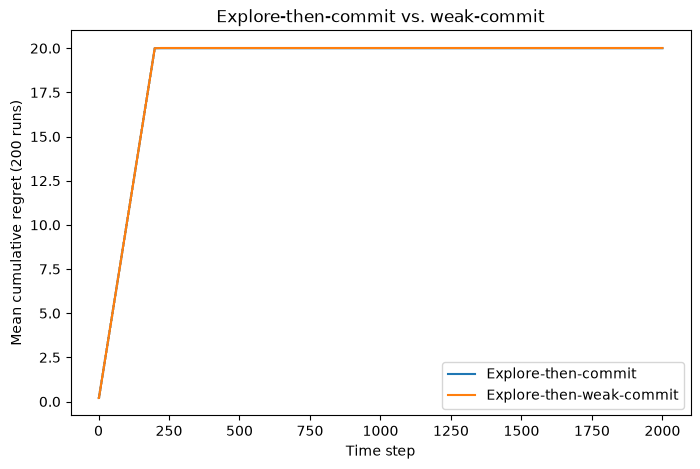

Explore-then-commit: mean final regret = 20.00
Explore-then-weak-commit: mean final regret = 20.01


In [13]:
import importlib
import bandit_algorithm

bandit_algorithm = importlib.reload(bandit_algorithm)
ExploreThenCommit = bandit_algorithm.ExploreThenCommit
ExploreThenWeakCommit = bandit_algorithm.ExploreThenWeakCommit

n_comparison_runs = 200
algorithm_classes = [
    ("Explore-then-commit", ExploreThenCommit),
    ("Explore-then-weak-commit", ExploreThenWeakCommit),
]
regret_samples = {
    name: np.zeros((n_comparison_runs, time_horizon))
    for name, _ in algorithm_classes
}

for run in range(n_comparison_runs):
    run_seed = 5000 + run
    for name, algorithm_class in algorithm_classes:
        environment = BernoulliBandit(
            probabilities=prob_vec, random_seed=run_seed
        )
        algorithm = algorithm_class(
            n_arms=n_arms,
            T_explore=explore_time_etc,
            random_seed=run_seed,
        )
        cumulative_regret = 0.0
        for timestep in range(time_horizon):
            chosen_arm = algorithm.select_arm()
            reward = environment.pull_arm(chosen_arm)
            algorithm.update(chosen_arm, reward)
            cumulative_regret += environment.get_regret(chosen_arm)
            regret_samples[name][run, timestep] = cumulative_regret

plt.figure(figsize=(8, 5))
time_steps = np.arange(1, time_horizon + 1)
for name, _ in algorithm_classes:
    plt.plot(time_steps, regret_samples[name].mean(axis=0), label=name)
plt.grid(True, alpha=0.3)
finalize_plot(
    xlabel="Time step",
    ylabel=f"Mean cumulative regret ({n_comparison_runs} runs)",
    title="Explore-then-commit vs. weak-commit",
)

for name, _ in algorithm_classes:
    print(f"{name}: mean final regret = {regret_samples[name][:, -1].mean():.2f}")

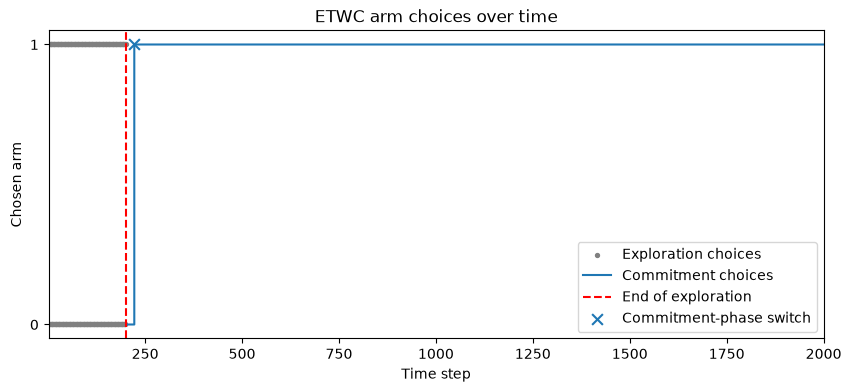

Commitment-phase switches at time steps: [222]


In [15]:
trajectory_seed = 274
trajectory_environment = BernoulliBandit(
    probabilities=prob_vec, random_seed=trajectory_seed
)
trajectory_algorithm = ExploreThenWeakCommit(
    n_arms=n_arms,
    T_explore=explore_time_etc,
    random_seed=trajectory_seed,
)

for timestep in range(time_horizon):
    chosen_arm = trajectory_algorithm.select_arm()
    reward = trajectory_environment.pull_arm(chosen_arm)
    trajectory_algorithm.update(chosen_arm, reward)

chosen_arms = np.array(trajectory_algorithm.arm_history)
switch_indices = np.flatnonzero(np.diff(chosen_arms) != 0) + 1
commitment_start = n_arms * explore_time_etc
switch_indices = switch_indices[switch_indices > commitment_start]
switch_times = switch_indices + 1
time_steps = np.arange(1, time_horizon + 1)

plt.figure(figsize=(10, 4))
plt.scatter(
    time_steps[:commitment_start],
    chosen_arms[:commitment_start],
    s=8,
    color="gray",
    label="Exploration choices",
)
plt.step(
    time_steps[commitment_start:],
    chosen_arms[commitment_start:],
    where="post",
    label="Commitment choices",
)
plt.axvline(
    x=commitment_start,
    color="red",
    linestyle="--",
    label="End of exploration",
)
plt.scatter(
    switch_times,
    chosen_arms[switch_indices],
    marker="x",
    s=60,
    label="Commitment-phase switch",
)
plt.yticks(np.arange(n_arms))
plt.xlim(1, time_horizon)
plt.grid(True, alpha=0.3)
finalize_plot(
    xlabel="Time step",
    ylabel="Chosen arm",
    title="ETWC arm choices over time",
)
print(f"Commitment-phase switches at time steps: {switch_times.tolist()}")

### Epsilon Greedy

In [15]:
# initialise environment
env2 = BernoulliBandit(probabilities=prob_vec, random_seed=seed_e_greedy)
# initialise bandit algorithm
e_greedy_alg = EpsilonGreedy(n_arms=n_arms, epsilon=eps, random_seed=seed_e_greedy)

In [16]:
# set up loop
regret = np.zeros(time_horizon)
for timestep in range(time_horizon):
    # algorithm chooses an arm
    chosen_arm = e_greedy_alg.select_arm()
    # environment provides a reward
    reward = env2.pull_arm(chosen_arm)
    # algorithm updates its internal state
    e_greedy_alg.update(chosen_arm, reward)
    # compute regret
    instant_regret = env2.get_regret(chosen_arm)
    if timestep == 0:
        regret[timestep] = instant_regret
    else:
        regret[timestep] = regret[timestep - 1] + instant_regret

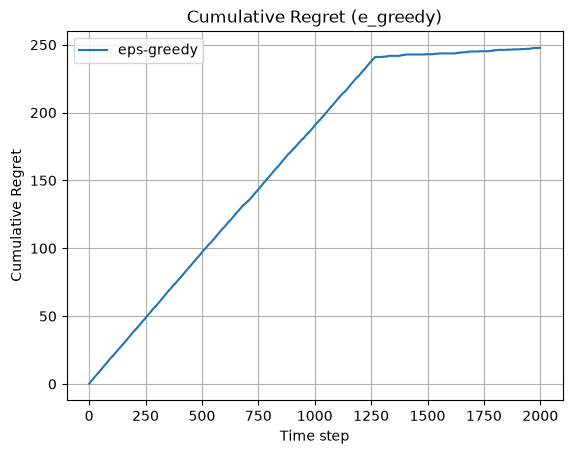

In [17]:
# plot regret
plt.plot(range(time_horizon), regret, label="eps-greedy")
finalize_plot(xlabel="Time step", ylabel="Cumulative Regret", title="Cumulative Regret (e_greedy)")

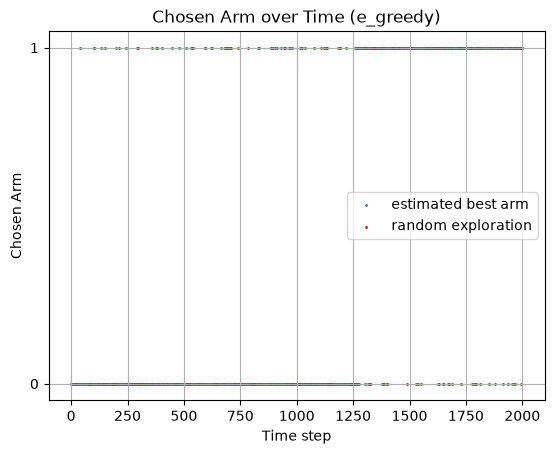

In [18]:
# plot chosen arm
chosen_arms = np.array(e_greedy_alg.arm_history)
plt.scatter(
    [i for i in range(time_horizon)
     if i not in e_greedy_alg.exploration_history],
    [
        chosen_arms[i]
        for i in range(time_horizon)
        if i not in e_greedy_alg.exploration_history
    ],
    label="estimated best arm",
    s=1,
)
plt.scatter(
    e_greedy_alg.exploration_history,
    [chosen_arms[i] for i in e_greedy_alg.exploration_history],
    label="random exploration",
    s=1,
    c="red",
)
plt.yticks(np.arange(n_arms))
finalize_plot(xlabel="Time step", ylabel="Chosen Arm", title="Chosen Arm over Time (e_greedy)")

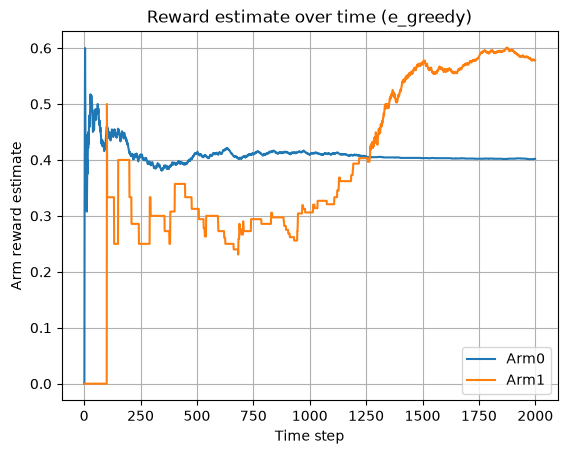

In [19]:
# plot arm estimates over time
for i in range(n_arms):
    plt.plot(range(time_horizon),
             e_greedy_alg.get_arms_estimates_history()[:, i],
             label="Arm" + str(i))
finalize_plot(xlabel="Time step", ylabel="Arm reward estimate", title="Reward estimate over time (e_greedy)")
